# Exercícios — Viés, Variância e Curvas de Aprendizado

**Tema:** Avaliação e Validação de Modelos › Viés, Variância e Curvas de Aprendizado

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score, learning_curve, validation_curve
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(646)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR, CINZA = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100", "#5A5A5A"
print("ambiente pronto")

ambiente pronto


---
## Dataset de trabalho: demanda horária de bicicletas compartilhadas

Uma operadora de bicicletas quer prever quantas retiradas cada estação
terá numa hora, para redistribuir bicicletas à noite. Cada linha é uma
(estação, hora): temperatura, chuva prevista, fim de semana, hora do
dia e distância da estação ao centro. A demanda real tem um pico de
temperatura (ninguém pedala a 38 °C), dois picos de hora em dia útil e
um só no fim de semana, e chuva que pesa mais no fim de semana.

Como o gerador é nosso, conhecemos a função verdadeira `f_demanda` e o
ruído `SIGMA`. Isso é o que permite **medir** viés e variância nos
exercícios 2 e 4; num problema real você só teria as curvas do
exercício 3.

Há também uma variável escondida, `evento` (shows, jogos, feiras perto da
estação), que a operadora **não** tem hoje. Ela entra no gerador como
parte do ruído e só aparece no exercício 5. Por causa dela o ruído não é
gaussiano (é uma mistura: 94% das horas sem evento, 6% com +14
retiradas), então o piso do MAE não é $\sigma\sqrt{2/\pi}$; calculamos
por simulação como o erro absoluto médio do ruído em torno da sua
mediana, que é o que o melhor previsor possível ainda erraria.

In [2]:
SIGMA = 5.0                                  # desvio total do ruído SEM a variável evento

def f_demanda(X):
    temp, chuva, fds, hora, dist = X.T
    pico_temp = np.exp(-((temp - 24) / 7) ** 2)
    hora_util = 22 * np.exp(-((hora - 8) / 1.3) ** 2) + 26 * np.exp(-((hora - 18) / 1.6) ** 2)
    hora_fds = 20 * np.exp(-((hora - 14) / 3) ** 2)
    horario = np.where(fds == 1, hora_fds, hora_util) + 6
    return (horario * (0.5 + pico_temp) * np.exp(-dist / 6)
            - chuva * (0.6 + 0.6 * fds))

def gera_demanda(n, semente, com_evento=False):
    g = np.random.default_rng(semente)
    temp = g.normal(24, 6, n)
    chuva = np.where(g.random(n) < 0.25, g.gamma(1.5, 3, n), 0.0)
    fds = (g.random(n) < 2 / 7).astype(int)
    hora = g.integers(0, 24, n)
    dist = g.gamma(2, 2, n)
    evento = (g.random(n) < 0.06).astype(int)
    X = np.column_stack([temp, chuva, fds, hora, dist])
    y = f_demanda(X) + 14 * evento + g.normal(0, SIGMA * 0.75, n)   # 14*evento + ruído restante
    if com_evento:
        return np.column_stack([X, evento]), y
    return X, y

X, y = gera_demanda(6000, 0)
colunas = ["temp", "chuva", "fds", "hora", "dist"]
ruido = 14 * (rng.random(200_000) < 0.06) + rng.normal(0, SIGMA * 0.75, 200_000)
PISO_MAE = np.mean(np.abs(ruido - np.median(ruido)))          # melhor MAE possível sem a coluna evento
PISO_MAE_COM_EVENTO = SIGMA * 0.75 * np.sqrt(2 / np.pi)       # o que sobra é gaussiano
print(f"{len(y)} linhas | demanda média {y.mean():.1f} retiradas/hora | desvio {y.std():.1f}")
print(f"desvio do ruído sem 'evento' (medido): {np.std(y - f_demanda(X)):.2f}")
print(f"piso do MAE sem 'evento': {PISO_MAE:.2f} | com 'evento': {PISO_MAE_COM_EVENTO:.2f}")

6000 linhas | demanda média 6.8 retiradas/hora | desvio 8.3
desvio do ruído sem 'evento' (medido): 4.98
piso do MAE sem 'evento': 3.64 | com 'evento': 2.99


---
## Exercício 1 🟢 — A decomposição na mão

Num ponto $x_0$ com $f(x_0) = 42$ e ruído $\sigma = 6$, dois algoritmos
foram treinados em 8 amostras de treino diferentes e previram:

- **A:** 40, 45, 38, 47, 41, 44, 39, 46
- **B:** 38, 39, 38, 40, 39, 38, 40, 39

Calcule viés², variância e erro esperado de cada um em $x_0$. Qual você
escolheria? E se a base de treino quadruplicasse?

In [3]:
# --- sua resposta ---

### Gabarito 1

In [4]:
f_x0, sigma = 42, 6
for nome, prev in [("A", [40, 45, 38, 47, 41, 44, 39, 46]), ("B", [38, 39, 38, 40, 39, 38, 40, 39])]:
    p = np.array(prev, dtype=float)
    vies2, var = (f_x0 - p.mean()) ** 2, p.var()          # var populacional: estima E[(f̂ - f̄)²]
    print(f"{nome}: média {p.mean():.3f} | viés² {vies2:.2f} | variância {var:.2f} | "
          f"ruído {sigma ** 2} | erro esperado {vies2 + var + sigma ** 2:.2f}")

A: média 42.500 | viés² 0.25 | variância 10.25 | ruído 36 | erro esperado 46.50
B: média 38.875 | viés² 9.77 | variância 0.61 | ruído 36 | erro esperado 46.38


**Por quê:** A quase não tem viés (média 42,5) mas espalha (variância
10,25); B mira torto (média 38,9, viés² 9,8) mas é firme (variância
0,6). Os erros esperados empatam, 46,5 contra 46,4, e o ruído responde
por mais de três quartos de ambos. Hoje, tanto faz. Com 4× mais dados,
a variância de A cai (a de um estimador típico cai como $1/n$, então
para perto de 2,6) e o viés de B fica onde está: A passa a vencer com
folga. Viés não é desqualificante e variância não é permanente; a
escolha depende de quanto dado vai existir.

---
## Exercício 2 🟢 — Medindo o k do k-NN

Com amostras de treino de 300 linhas sorteadas do gerador (use
`gera_demanda(300, semente)` com sementes diferentes) e uma grade fixa de
400 pontos de teste, meça viés², variância e erro esperado de um k-NN
(features padronizadas) para $k \in \{1, 3, 10, 30, 100\}$. Depois escolha
$k$ do jeito que se faz na prática: 5-fold numa **única** amostra de
300. A CV escolhe o mesmo $k$?

In [5]:
# --- sua resposta ---

### Gabarito 2

In [6]:
X_grade, _ = gera_demanda(400, 999)
f_grade = f_demanda(X_grade)
ks = [1, 3, 10, 30, 100]
knn = lambda k: make_pipeline(StandardScaler(), KNeighborsRegressor(k))

linhas = []
for k in ks:
    P = np.array([knn(k).fit(*gera_demanda(300, s)).predict(X_grade) for s in range(100)])
    vies2 = np.mean((f_grade - P.mean(axis=0)) ** 2)
    var = np.mean(P.var(axis=0))
    linhas.append({"k": k, "viés²": vies2, "variância": var, "erro esperado": vies2 + var + SIGMA ** 2})
medido = pd.DataFrame(linhas).set_index("k")
print(medido.round(2).to_string())

X1, y1 = gera_demanda(300, 7)
cv = {k: -cross_val_score(knn(k), X1, y1, cv=KFold(5, shuffle=True, random_state=0),
                          scoring="neg_mean_squared_error").mean() for k in ks}
print("\nMSE por 5-fold numa única amostra:", {k: round(float(v), 1) for k, v in cv.items()})
print(f"simulação escolhe k = {medido['erro esperado'].idxmin()} | CV escolhe k = {min(cv, key=cv.get)}")

     viés²  variância  erro esperado
k                                   
1     9.73      43.32          78.04
3    13.65      16.21          54.87
10   21.53       5.81          52.34
30   31.63       2.31          58.94
100  37.20       0.72          62.92

MSE por 5-fold numa única amostra: {1: 83.9, 3: 53.7, 10: 55.0, 30: 60.8, 100: 63.8}
simulação escolhe k = 10 | CV escolhe k = 3


**Por quê:** $k = 1$ é variância pura (o modelo copia o ruído do vizinho);
$k = 100$ com 300 pontos é viés (a média de um terço da base). O erro
esperado faz o U e o mínimo fica num $k$ intermediário. A CV numa única
amostra é uma estimativa ruidosa da mesma curva, e em geral aponta para
o mesmo $k$ ou um vizinho dele: é a versão praticável do que a simulação
faz com a função verdadeira. Repare que o MSE da CV inclui o ruído
($\sigma^2 = 25$) e por isso fica na mesma escala do erro esperado.

---
## Exercício 3 🟡 — Diagnóstico por curvas de aprendizado

Trace as curvas de aprendizado (MAE de treino e de validação, 5-fold)
de uma ridge com features padronizadas e de um
`HistGradientBoostingRegressor` para $n$ de 150 a 4.800. Diagnostique cada
modelo. Depois ajuste a lei de potência $a + b\,n^{-c}$ à curva de
validação do boosting e estime: (a) o piso, comparando com `PISO_MAE`;
(b) quantas linhas seriam necessárias para MAE de 3,75. (c) Refaça o
ajuste **fixando** $a$ no piso conhecido e compare a resposta de (b).

In [7]:
# --- sua resposta ---

### Gabarito 3

--- ridge
   n  treino  validação
 150    5.67       5.83
 300    5.69       5.73
 600    5.77       5.72
1200    5.76       5.71
2400    5.68       5.68
4800    5.67       5.68


--- boosting
   n  treino  validação
 150    2.87       5.47
 300    2.28       5.06
 600    1.97       4.78
1200    2.19       4.39
2400    2.68       4.06
4800    3.00       3.89

ajuste livre : 2.69 + 10.1·n^(-0.25)  -> piso estimado 2.69 (real: 3.64)
ajuste com a fixo no piso: 3.64 + 36.2·n^(-0.57)
n para MAE = 3.75: ajuste livre 7,505 linhas | com a fixo 29,059 linhas


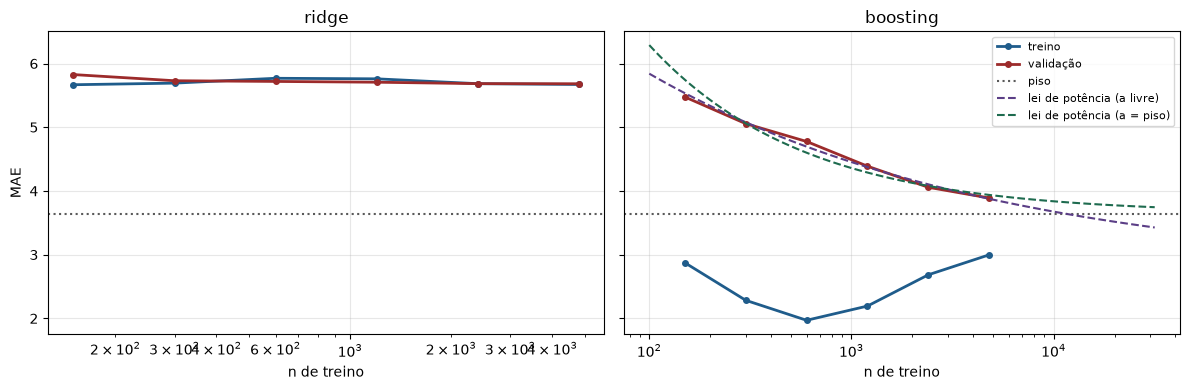

In [8]:
tamanhos = np.array([150, 300, 600, 1200, 2400, 4800])
modelos = {"ridge": make_pipeline(StandardScaler(), Ridge(1.0)),
           "boosting": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=0)}
curvas = {}
for nome, m in modelos.items():
    n_, tr, va = learning_curve(m, X, y, train_sizes=tamanhos, cv=KFold(5, shuffle=True, random_state=0),
                                scoring="neg_mean_absolute_error", shuffle=True, random_state=0)
    curvas[nome] = pd.DataFrame({"n": n_, "treino": -tr.mean(axis=1), "validação": -va.mean(axis=1)})
    print(f"--- {nome}\n{curvas[nome].round(2).to_string(index=False)}")

lei = lambda n, a, b, c: a + b * n ** (-c)
cb = curvas["boosting"]
pesos = 1 / np.sqrt(cb["n"])
(a, b, c), _ = curve_fit(lei, cb["n"], cb["validação"], p0=[4, 20, 0.5], sigma=pesos, maxfev=20000)
(b_f, c_f), _ = curve_fit(lambda n, b, c: lei(n, PISO_MAE, b, c), cb["n"], cb["validação"],
                          p0=[20, 0.5], sigma=pesos, maxfev=20000)
lei_fixa = lambda n: lei(n, PISO_MAE, b_f, c_f)
ALVO = 3.75
n_livre = (b / (ALVO - a)) ** (1 / c)
n_fixo = (b_f / (ALVO - PISO_MAE)) ** (1 / c_f)
print(f"\najuste livre : {a:.2f} + {b:.1f}·n^(-{c:.2f})  -> piso estimado {a:.2f} (real: {PISO_MAE:.2f})")
print(f"ajuste com a fixo no piso: {PISO_MAE:.2f} + {b_f:.1f}·n^(-{c_f:.2f})")
print(f"n para MAE = {ALVO}: ajuste livre {n_livre:,.0f} linhas | com a fixo {n_fixo:,.0f} linhas")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (nome, cv_) in zip(axes, curvas.items()):
    ax.plot(cv_["n"], cv_["treino"], color=AZUL, marker="o", ms=4, lw=2, label="treino")
    ax.plot(cv_["n"], cv_["validação"], color=VERMELHO, marker="o", ms=4, lw=2, label="validação")
    ax.axhline(PISO_MAE, color=CINZA, ls=":", label="piso"); ax.set_xscale("log"); ax.set_title(nome)
    ax.set_xlabel("n de treino")
grade_n = np.logspace(2, 4.5, 100)
axes[1].plot(grade_n, lei(grade_n, a, b, c), color=ROXO, lw=1.5, ls="--", label="lei de potência (a livre)")
axes[1].plot(grade_n, lei_fixa(grade_n), color=VERDE, lw=1.5, ls="--", label="lei de potência (a = piso)")
axes[0].set_ylabel("MAE"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Por quê:** a ridge converge cedo com treino e validação juntos, longe
do piso: viés. A relação tem picos de hora e um pico de temperatura que
uma reta em cinco features não representa, e nenhum $n$ muda isso. O
boosting mostra o vão que fecha com $n$ e a validação descendo em
direção ao piso: variância, que dados curam.

O ajuste livre da lei de potência estima o piso **bem abaixo** do real:
com seis pontos e uma curva ainda em queda, os três parâmetros
encontram várias combinações quase equivalentes, e o $a$ que sai é
pouco confiável. É o alerta da seção 5 do notebook 2, agora com
consequência: o $n$ para a meta de 3,75 sai otimista. Quando existe uma
estimativa independente do piso (aqui, o gerador; na vida real,
observações repetidas ou concordância entre rotuladores), fixar $a$ e
ajustar só $b$ e $c$ dá uma extrapolação bem mais honesta, e o $n$
necessário sobe. Uma meta abaixo do piso recebe a resposta "não com
estas features", e o exercício 5 mostra de onde viria a feature.

---
## Exercício 4 🟡 — O vão da curva de validação é variância

Com $n = 1.500$, trace a curva de validação do boosting em
`max_leaf_nodes` $\in \{3, 7, 15, 31, 63, 127\}$ (MAE de treino e de
validação). Depois, para três desses valores (3, 15 e 127), meça viés² e
variância por simulação (30 amostras de treino de 1.500 linhas, grade de
teste fixa) e confira: o vão entre as curvas cresce junto com a
variância medida?

In [9]:
# --- sua resposta ---

### Gabarito 4

In [10]:
folhas = [3, 7, 15, 31, 63, 127]
hgb = lambda m: HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1, max_leaf_nodes=m,
                                              min_samples_leaf=5, random_state=0)
idx = rng.choice(len(y), 1500, replace=False)
tr, va = validation_curve(hgb(31), X[idx], y[idx], param_name="max_leaf_nodes", param_range=folhas,
                          cv=KFold(5, shuffle=True, random_state=0), scoring="neg_mean_absolute_error")
curva_val = pd.DataFrame({"max_leaf_nodes": folhas, "MAE treino": -tr.mean(axis=1),
                          "MAE validação": -va.mean(axis=1)})
curva_val["vão"] = curva_val["MAE validação"] - curva_val["MAE treino"]
print(curva_val.round(2).to_string(index=False))

print("\nmedido por simulação (30 amostras de treino):")
for m in [3, 15, 127]:
    P = np.array([hgb(m).fit(*gera_demanda(1500, s)).predict(X_grade) for s in range(30)])
    print(f"  max_leaf_nodes = {m:3d}: viés² {np.mean((f_grade - P.mean(axis=0)) ** 2):6.2f} | "
          f"variância {np.mean(P.var(axis=0)):6.2f}")

 max_leaf_nodes  MAE treino  MAE validação  vão
              3        4.35           4.71 0.37
              7        3.07           4.19 1.11
             15        2.17           4.24 2.07
             31        1.23           4.35 3.12
             63        0.49           4.51 4.02
            127        0.09           4.69 4.60

medido por simulação (30 amostras de treino):


  max_leaf_nodes =   3: viés²  12.85 | variância   1.50


  max_leaf_nodes =  15: viés²   2.53 | variância   4.73


  max_leaf_nodes = 127: viés²   3.57 | variância  10.67


**Por quê:** com 3 folhas por árvore o boosting é quase aditivo e não
captura as interações (hora × fim de semana, chuva × fim de semana):
viés alto, vão pequeno. Com 127 folhas e 1.500 linhas, cada árvore
recorta o ruído: o viés² não melhora em relação a 15 folhas (a
flexibilidade extra já não compra nada), a variância mais que dobra e o
vão fica largo. A curva de validação, que não sabe nada de $f$, reproduz
a ordem das variâncias medidas. É essa correspondência que autoriza usar
o vão como termômetro de variância em dados reais.

---
## Exercício 5 🔴 — Onde investir o próximo trimestre

A operadora tem 6.000 linhas e três propostas na mesa:

- **(a)** Esperar mais um ano de operação e retreinar com **12.000**
  linhas (custo: um ano).
- **(b)** Contratar uma API de eventos da cidade (custo: R$ 40 mil/ano),
  que entregaria a coluna `evento` para cada (estação, hora).
- **(c)** Trocar o boosting por uma rede neural (custo: dois meses de
  uma pessoa).

A meta do time é MAE ≤ 3,5 retiradas/hora. Use as ferramentas do módulo
para avaliar as três propostas: extrapole a curva de aprendizado para
(a), estime o novo piso e o novo MAE para (b) (use
`gera_demanda(..., com_evento=True)`), e argumente sobre (c) a partir do
diagnóstico. Recomende.

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
# (a) o que 12.000 linhas comprariam, segundo a lei de potência com a fixo no piso
print(f"(a) MAE previsto com 12.000 linhas: {lei_fixa(12000):.2f} (hoje, 4.800: {cb['validação'].iloc[-1]:.2f}; "
      f"piso sem 'evento': {PISO_MAE:.2f})")

# (b) com a coluna evento, o ruído restante é gaussiano com desvio SIGMA*0.75 e o piso cai
Xe, ye = gera_demanda(6000, 0, com_evento=True)
n_e, tr_e, va_e = learning_curve(modelos["boosting"], Xe, ye, train_sizes=tamanhos,
                                 cv=KFold(5, shuffle=True, random_state=0),
                                 scoring="neg_mean_absolute_error", shuffle=True, random_state=0)
mae_evento = -va_e.mean(axis=1)
print(f"(b) MAE com 'evento' e 4.800 linhas: {mae_evento[-1]:.2f} (novo piso: {PISO_MAE_COM_EVENTO:.2f})")

# (c) o diagnóstico do exercício 3
vao = cb["validação"].iloc[-1] - cb["treino"].iloc[-1]
print(f"(c) vão treino-validação do boosting em 4.800 linhas: {vao:.2f}; "
      f"distância ao piso: {cb['validação'].iloc[-1] - PISO_MAE:.2f}")

(a) MAE previsto com 12.000 linhas: 3.82 (hoje, 4.800: 3.89; piso sem 'evento': 3.64)


(b) MAE com 'evento' e 4.800 linhas: 3.18 (novo piso: 2.99)
(c) vão treino-validação do boosting em 4.800 linhas: 0.89; distância ao piso: 0.24


**Como avaliar sua resposta:** a meta de 3,5 está **abaixo do piso** das
features atuais (≈ 3,65): nenhuma quantidade de dados e nenhum modelo
chega lá. Isso descarta (a) e (c) como caminhos para a meta, e a
extrapolação da curva confirma que dobrar $n$ compra um décimo. A
proposta (b) muda o piso, não o modelo: `evento` tira do ruído uma parte
que era previsível, o novo piso fica perto de 3,0 e o boosting com a
coluna nova chega abaixo de 3,5 já com os dados de hoje. A recomendação é
(b), com uma condição que uma boa resposta explicita: a API precisa
entregar `evento` **no instante da previsão** (a noite anterior), senão
é vazamento (módulo 3). Sobre (c): a validação do boosting está a poucos
décimos do piso; o vão que resta é o que 4.800 linhas permitem, e um
modelo mais flexível só teria variância para adicionar. Uma resposta
completa também converte a recomendação para a linguagem de quem paga:
R$ 40 mil por ano contra o custo de bicicletas paradas na estação
errada, que é o que o MAE mede.

---
## Fechamento

- Viés² e variância se calculam sobre a distribuição das previsões em
  amostras de treino diferentes; o ruído entra por fora e domina mais do
  que parece.
- Viés não desqualifica um algoritmo; variância não é permanente. A
  escolha depende de quanto dado vai existir.
- A CV numa amostra é a versão praticável da curva em U.
- Nas curvas de aprendizado: convergir alto é viés, vão é variância,
  plano perto do piso é fim de linha para aquelas features.
- Antes de comprar dados ou trocar de modelo, compare a meta com o piso.

→ Próximo módulo: **Calibração de Probabilidades**.